In [ ]:
# Pytorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-Learn imports
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Matplotlib imports
import matplotlib.pyplot as plt

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

In [29]:
X, y = load_breast_cancer(return_X_y=True)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (569, 30)
y shape: (569,)


In [30]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    random_state=RANDOM_SEED,
    test_size=0.2,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    random_state=RANDOM_SEED,
    test_size=0.2,
    stratify=y_train_full
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (364, 30)
y_train shape: (364,)
X_test shape: (114, 30)
y_test shape: (114,)
X_test shape: (91, 30)
y_test shape: (91,)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [32]:
X_train_scaled_tensor = torch.from_numpy(X_train_scaled).float()
X_test_scaled_tensor = torch.from_numpy(X_test_scaled).float()
X_val_scaled_tensor = torch.from_numpy(X_val_scaled).float()

y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)
y_val_tensor = torch.from_numpy(y_val).float().unsqueeze(1)

print(f"X_train_tensor shape: {tuple(X_train_scaled_tensor.shape)}")
print(f"y_train_tensor shape: {tuple(y_train_tensor.shape)}, y_train_tensor.dtype: {y_train_tensor.dtype}")
print(f"X_test_tensor shape: {tuple(X_test_scaled_tensor.shape)}")
print(f"y_test_tensor shape: {tuple(y_test_tensor.shape)}, y_test_tensor.dtype: {y_test_tensor.dtype}")

X_train_tensor shape: (364, 30)
y_train_tensor shape: (364, 1), y_train_tensor.dtype: torch.float32
X_test_tensor shape: (114, 30)
y_test_tensor shape: (114, 1), y_test_tensor.dtype: torch.float32


In [33]:
train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)

dataloader_generator = torch.Generator().manual_seed(RANDOM_SEED)
train_loader = DataLoader(
    train_dataset,
    generator=dataloader_generator,
    batch_size=32,
    shuffle=True
)

In [44]:
class BCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=30, out_features=64)
        self.layer2 = nn.Linear(in_features=64, out_features=32)
        self.dropout = nn.Dropout(0.4)
        self.layer_out = nn.Linear(in_features=32, out_features=1)

    def forward(self, x):
        output = self.layer1(x)
        output = torch.relu(output)
        output = self.layer2(output)
        output = torch.relu(output)
        output = self.dropout(output)
        output = self.layer_out(output)
        output = torch.sigmoid(output)

        return output

In [45]:
model = BCNet()
loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [46]:
epoch_count = 20

loss_history = []
accuracy_history = []
val_loss_history = []
val_acc_history = []
print(f"{' ':5s} | {'Train':>10s} | {'Train':>10s}")
print(f"{'Epoch':5s} | {'Loss':>10s} | {'Accuracy':>10s}")

for epoch in range(epoch_count):
    model.train()
    
    running_loss = 0.0
    running_accuracy = 0.0
    iter_count = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        probs = model(x_batch)
        loss = loss_function(probs, y_batch)

        loss.backward()
        optimizer.step()
        
        preds = (probs > 0.5).float()
        acc: float = (preds == y_batch).float().mean().item()

        running_loss += loss.item()
        running_accuracy += acc
        iter_count += 1

    model.eval()
    with torch.no_grad():
        val_probs = model(X_val_scaled_tensor)
        val_loss = loss_function(val_probs, y_val_tensor).item()
    
        val_preds = (val_probs > 0.5).float()
        val_accuracy = (val_preds == y_val_tensor).float().mean().item()

        val_loss_history.append(val_loss)
        val_acc_history.append(val_accuracy)

    epoch_loss = running_loss / iter_count
    epoch_accuracy = running_accuracy / iter_count
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    print(f"{(epoch + 1):5d} | {epoch_loss:10.4f} | {epoch_accuracy:10.4f}")

      |      Train |      Train
Epoch |       Loss |   Accuracy
    1 |     0.6652 |     0.6484
    2 |     0.5630 |     0.8984
    3 |     0.4279 |     0.9306
    4 |     0.3116 |     0.9358
    5 |     0.2105 |     0.9505
    6 |     0.1509 |     0.9609
    7 |     0.1268 |     0.9635
    8 |     0.1095 |     0.9722
    9 |     0.0764 |     0.9792
   10 |     0.0759 |     0.9766
   11 |     0.0708 |     0.9870
   12 |     0.0574 |     0.9844
   13 |     0.0553 |     0.9896
   14 |     0.0538 |     0.9896
   15 |     0.0649 |     0.9852
   16 |     0.0526 |     0.9922
   17 |     0.0402 |     0.9922
   18 |     0.0431 |     0.9922
   19 |     0.0405 |     0.9922
   20 |     0.0432 |     0.9922


<Figure size 800x400 with 0 Axes>

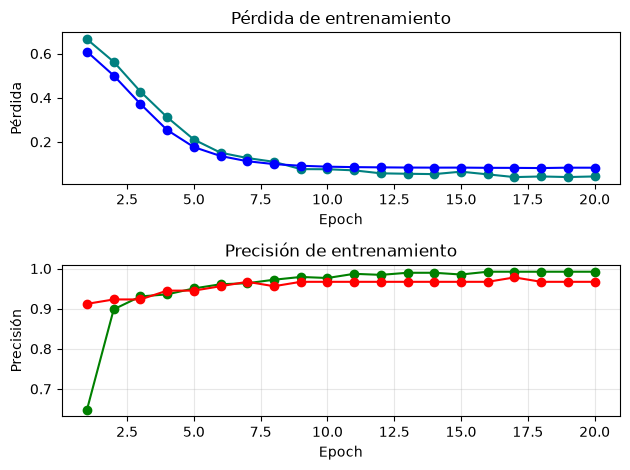

In [47]:
epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))

fig, (ax0, ax1) = plt.subplots(2)
# fig.suptitle("Pérdida y Precisión de entrenamiento")

ax0.plot(epochs, loss_history, marker="o", color="teal")
ax0.plot(epochs, val_loss_history, marker="o", color="blue")
ax0.set(xlabel="Epoch", ylabel="Pérdida")
ax0.set_title("Pérdida de entrenamiento")

ax1.plot(epochs, accuracy_history, marker="o", color="green")
ax1.plot(epochs, val_acc_history, marker="o", color="red")
ax1.set(xlabel="Epoch", ylabel="Precisión")
ax1.set_title("Precisión de entrenamiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
model.eval()

with torch.no_grad():
    test_probs = model(X_test_scaled_tensor)
    test_loss = loss_function(test_probs, y_test_tensor).item()

    test_preds = (test_probs > 0.5).float()
    accuracy = (test_preds == y_test_tensor).float().mean().item()

print(f"Pérdida de prueba: {test_loss:.4f}")
print(f"Exactitud de prueba: {accuracy:.2%}")

Pérdida de prueba: 0.0943
Exactitud de prueba: 96.49%
